# Data analysis with python

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
dataset=pd.read_csv("data/prod_data3.csv")

In [6]:
dataset

,Quality Index,Apple1,Apple2,Apple3,Apple4,Apple5,Apple6,Apple7,Percentage,Date Update
0,Count,35,23,16,76,7,10,87,1.0,01/01/26
1,Color,NaN,Passed,Not Passed,Passed,Passed,Passed,Passed,0.7,01/02/26
2,Flavor,Passed,NaN,Passed,NaN,NaN,Not Passed,Passed,0.6,01/03/26
3,Freshnesh,Passed,Not Passed,Passed,Passed,Passed,Passed,Passed,0.4,01/04/26


In [7]:
# Get the row where Quality Index == 'Count'
count_row = dataset[dataset['Quality Index'] == 'Count'].iloc[0]
count_row

Quality Index       Count
Apple1                 35
Apple2                 23
Apple3                 16
Apple4                 76
Apple5                  7
Apple6                 10
Apple7                 87
Percentage            1.0
Date Update      01/01/26
Name: 0, dtype: object

In [8]:

apple_cols = [col for col in dataset.columns if col.startswith('Apple')]
apple_cols

['Apple1', 'Apple2', 'Apple3', 'Apple4', 'Apple5', 'Apple6', 'Apple7']

In [9]:
# Create a dictionary of column names and their count values
# - Converts count values from the count_row into a dictionary
# - Maps each Apple column name to its count value (e.g., 'Apple1': 35)
count_dict = {col: int(count_row[col]) for col in apple_cols}
count_dict

{'Apple1': 35,
 'Apple2': 23,
 'Apple3': 16,
 'Apple4': 76,
 'Apple5': 7,
 'Apple6': 10,
 'Apple7': 87}

In [10]:
# Sort Apple columns by count (descending)
# - Sorts Apple column names based on their count values in descending order
# - Result: ['Apple7' (87), 'Apple4' (76), 'Apple1' (35), ...]
sorted_apple_cols = sorted(count_dict.keys(), key=lambda x: count_dict[x], reverse=True)
sorted_apple_cols

['Apple7', 'Apple4', 'Apple1', 'Apple2', 'Apple3', 'Apple6', 'Apple5']

In [11]:
#  Identify other columns
# - Finds columns that are not Apple columns and not 'Index' or 'Quality Index'
# - These are 'Percentage' and 'Date Update'

other_cols = [col for col in dataset.columns 
              if col not in apple_cols and col not in ['Index', 'Quality Index']]
other_cols

['Percentage', 'Date Update']

## Reorder with index

In [12]:
# Creation of a new column order to reorder dataset columns
# Creates new column order: ['Index', 'Quality Index'] + sorted Apple columns + other columns
new_column_order = ['Index', 'Quality Index'] + sorted_apple_cols + other_cols
new_column_order

['Index',
 'Quality Index',
 'Apple7',
 'Apple4',
 'Apple1',
 'Apple2',
 'Apple3',
 'Apple6',
 'Apple5',
 'Percentage',
 'Date Update']

In [13]:
type(new_column_order)

list

In [14]:
# Reorders the dataframe
# Reorders the dataframe to prioritize high-count Apple columns first

#dataset = dataset[new_column_order]# 'dataset' holds the input data for this script

## Reorder with no index

In [15]:
new_column_order_no_index = ['Quality Index'] + sorted_apple_cols + other_cols

In [16]:
# Reorders the dataframe
# Reorders the dataframe to prioritize high-count Apple columns first
# Remove 'Index' column from the ordering
dataset = dataset[new_column_order_no_index]
dataset

,Quality Index,Apple7,Apple4,Apple1,Apple2,Apple3,Apple6,Apple5,Percentage,Date Update
0,Count,87,76,35,23,16,10,7,1.0,01/01/26
1,Color,Passed,Passed,NaN,Passed,Not Passed,Passed,Passed,0.7,01/02/26
2,Flavor,Passed,NaN,Passed,NaN,Passed,Not Passed,NaN,0.6,01/03/26
3,Freshnesh,Passed,Passed,Passed,Not Passed,Passed,Passed,Passed,0.4,01/04/26


# Data visualization

## Matplotlib

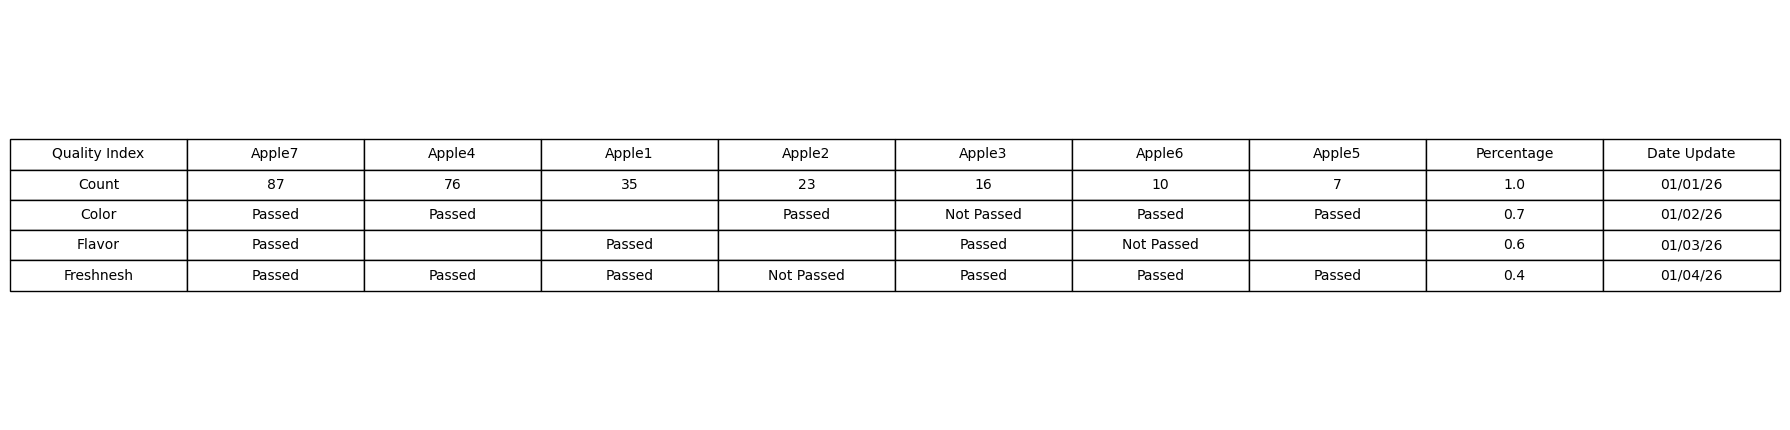

In [17]:
import matplotlib.pyplot as plt

# Create a matplotlib table from the full dataset
fig, ax = plt.subplots(figsize=(18, 2 + 0.6 * len(dataset)))
ax.axis('off')

table_data = dataset.fillna('').values
col_labels = dataset.columns.tolist()

tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

plt.tight_layout()
plt.show()

## Seaborn

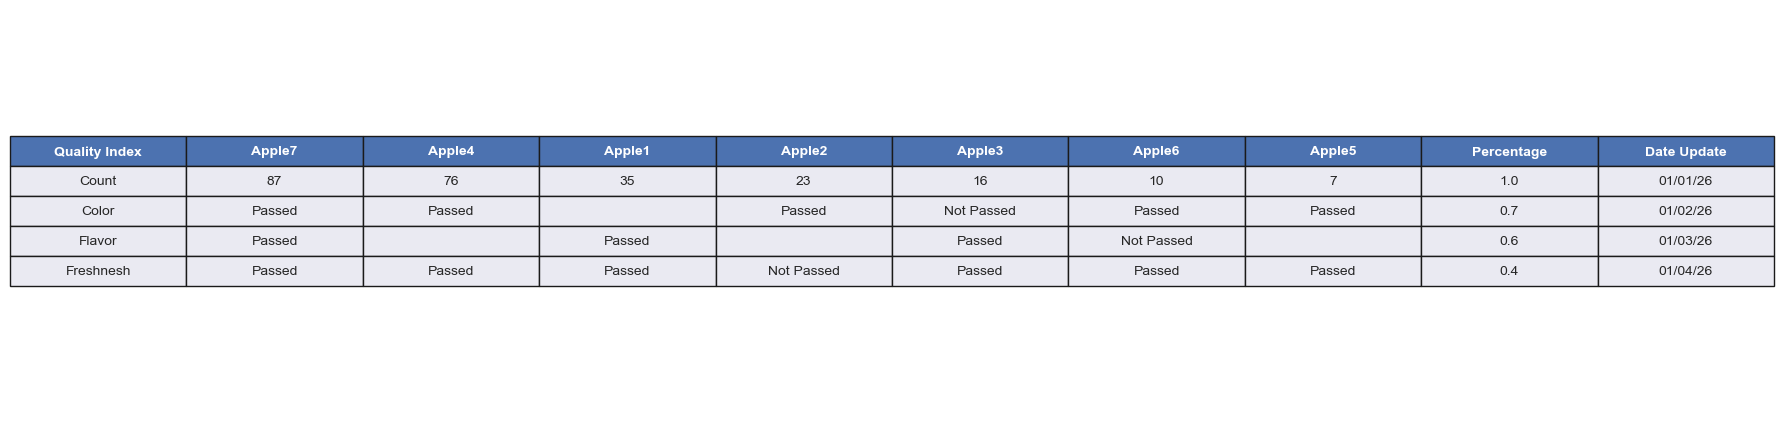

In [19]:
# Seaborn-styled table from the full dataset
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(18, 2 + 0.6 * len(dataset)))
ax.axis("off")

tbl = ax.table(
    cellText=dataset.fillna("").values,
    colLabels=dataset.columns.tolist(),
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

# Apply seaborn-like header/body colors
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4C72B0")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#EAEAF2")

plt.tight_layout()
plt.show()

### Seaborn table updates

- Format `Date Update` as `MM/DD/YY`
- Highlight cells containing `"Passed"` in green


C:\Users\rl-work\AppData\Local\Temp\ipykernel_20576\4189356388.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['Date Update'] = pd.to_datetime(dataset['Date Update'], errors='coerce').dt.strftime('%m/%d/%y')


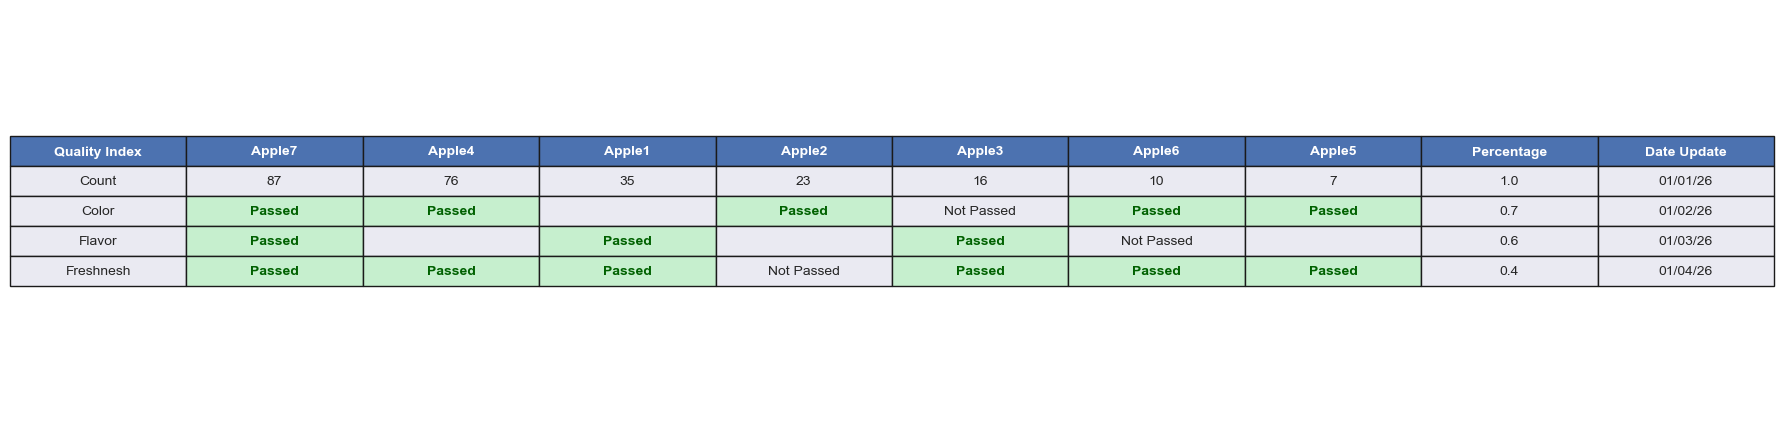

In [21]:


# Ensure Date Update is MM/DD/YY
dataset['Date Update'] = pd.to_datetime(dataset['Date Update'], errors='coerce').dt.strftime('%m/%d/%y')

# Seaborn-styled table
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(18, 2 + 0.6 * len(dataset)))
ax.axis("off")

tbl = ax.table(
    cellText=dataset.fillna("").values,
    colLabels=dataset.columns.tolist(),
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4C72B0")
        cell.set_text_props(color="white", weight="bold")
    else:
        val = str(cell.get_text().get_text()).strip()
        if val == "Passed":
            cell.set_facecolor("#C6EFCE")      # light green
            cell.set_text_props(color="#006100", weight="bold")
        else:
            cell.set_facecolor("#EAEAF2")

plt.tight_layout()
plt.show()


# Python code 

````python
# Run in Power Query: Transform > Run Python Script
import pandas as pd

# Get the row where Quality Index == 'Count'
count_row = dataset[dataset['Quality Index'] == 'Count'].iloc[0]

# Find all Apple columns
apple_cols = [col for col in dataset.columns if col.startswith('Apple')]

# Create a dictionary of column names and their count values
count_dict = {col: int(count_row[col]) for col in apple_cols}

# Sort Apple columns by count (descending)
sorted_apple_cols = sorted(count_dict.keys(), key=lambda x: count_dict[x], reverse=True)

# Reorder all columns: keep Index and Quality Index first, 
# then sorted Apple columns, then the rest
other_cols = [col for col in dataset.columns 
              if col not in apple_cols and col not in ['Index', 'Quality Index']]

#new_column_order = ['Index', 'Quality Index'] + sorted_apple_cols + other_cols
new_column_order = ['Quality Index'] + sorted_apple_cols + other_cols

# Reorder the dataframe
dataset = dataset[new_column_order]
````